In [1]:
!pip install kaggle


In [2]:
from google.colab import files
files.upload()  # This will prompt you to upload the kaggle.json file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shaba2643","key":"fe083efdd3794236a5f25fe6c2559944"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
!kaggle competitions download -c digit-recognizer

In [8]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.preprocessing import StandardScaler

# Define transformations for the training and test sets with augmentation
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert 1 channel to 3 channels
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Fixed std parameter
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert 1 channel to 3 channels
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Fixed std parameter
])

# Load the MNIST dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# Define a ResNet-based model
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, temperature=1.0):
        super(ResNetFeatureExtractor, self).__init__()
        self.temperature = temperature
        self.base_model = models.resnet18(pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])  # Extract up to the second last layer
        self.fc = nn.Linear(self.base_model.fc.in_features, 10)

    def forward(self, x, return_features=False):
        x = self.features(x)
        x = torch.flatten(x, 1)
        if return_features:
            return x  # Return intermediate features for attack
        x = self.fc(x) / self.temperature
        return x

# Initialize the teacher model
teacher_net = ResNetFeatureExtractor(temperature=10.0).to("cuda")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(teacher_net.parameters(), lr=0.0005, weight_decay=5e-4)

# Train the teacher model
epochs = 20
for epoch in range(epochs):
    teacher_net.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to("cuda"), data[1].to("cuda")
        optimizer.zero_grad()
        outputs = teacher_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(trainloader):.4f}')

print('Finished Training Teacher Model')

# Generate soft labels using the trained teacher model
def generate_soft_labels(model, dataloader):
    model.eval()
    soft_labels = []
    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.to("cuda")
            outputs = model(inputs)
            soft_labels.append(F.softmax(outputs / 10.0, dim=1).cpu().numpy())  # Temperature during training
    return np.concatenate(soft_labels)

train_soft_labels = generate_soft_labels(teacher_net, trainloader)

# Initialize the student model
student_net = ResNetFeatureExtractor(temperature=1.0).to("cuda")
optimizer = optim.Adam(student_net.parameters(), lr=0.0005, weight_decay=5e-4)

# Custom loss function to incorporate soft labels
def distillation_loss(y, labels, teacher_scores, T, alpha=0.5):
    return nn.KLDivLoss()(F.log_softmax(y / T, dim=1), F.softmax(teacher_scores / T, dim=1)) * (T * T * alpha) + \
           F.cross_entropy(y, labels) * (1. - alpha)

# Train the student model
for epoch in range(epochs):
    student_net.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to("cuda"), data[1].to("cuda")
        teacher_outputs = teacher_net(inputs)
        optimizer.zero_grad()
        student_outputs = student_net(inputs)
        loss = distillation_loss(student_outputs, labels, teacher_outputs, T=10.0, alpha=0.7)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(trainloader):.4f}')

print('Finished Training Student Model')

# Extract features from the model
def extract_features(model, dataloader):
    features = []
    labels = []
    model.eval()
    with torch.no_grad():
        for data in dataloader:
            images, targets = data[0].to("cuda"), data[1].to("cuda")
            outputs = model(images, return_features=True)
            features.append(outputs.cpu().numpy())
            labels.append(targets.cpu().numpy())
    return np.concatenate(features), np.concatenate(labels)

train_features, train_labels = extract_features(student_net, trainloader)
test_features, test_labels = extract_features(student_net, testloader)

# Normalize features
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# Train classifiers
svm_clf = SVC(probability=True)
svm_clf.fit(train_features, train_labels)

nb_clf = GaussianNB()
nb_clf.fit(train_features, train_labels)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(train_features, train_labels)

dt_clf = DecisionTreeClassifier(max_depth=10)
dt_clf.fit(train_features, train_labels)

ensemble_clf = VotingClassifier(estimators=[
    ('svm', svm_clf), ('nb', nb_clf), ('knn', knn_clf), ('dt', dt_clf)], voting='soft')
ensemble_clf.fit(train_features, train_labels)

# Evaluate classifiers
def evaluate_model(clf, test_features, test_labels, name):
    preds = clf.predict(test_features)
    acc = accuracy_score(test_labels, preds)
    print(f'{name} Accuracy: {acc * 100:.2f}%')
    return acc

print("\nEvaluating on Original Features:")
evaluate_model(svm_clf, test_features, test_labels, 'SVM')
evaluate_model(nb_clf, test_features, test_labels, 'Naive Bayes')
evaluate_model(knn_clf, test_features, test_labels, 'k-NN')
evaluate_model(dt_clf, test_features, test_labels, 'Decision Tree')
evaluate_model(ensemble_clf, test_features, test_labels, 'Ensemble')


Epoch 1/20, Loss: 0.3327
Epoch 2/20, Loss: 0.1526
Epoch 3/20, Loss: 0.1336
Epoch 4/20, Loss: 0.1230
Epoch 5/20, Loss: 0.1142
Epoch 6/20, Loss: 0.1092
Epoch 7/20, Loss: 0.1042
Epoch 8/20, Loss: 0.1031
Epoch 9/20, Loss: 0.0978
Epoch 10/20, Loss: 0.0961
Epoch 11/20, Loss: 0.0969
Epoch 12/20, Loss: 0.0891
Epoch 13/20, Loss: 0.0868
Epoch 14/20, Loss: 0.0901
Epoch 15/20, Loss: 0.0883
Epoch 16/20, Loss: 0.0865
Epoch 17/20, Loss: 0.0841
Epoch 18/20, Loss: 0.0862
Epoch 19/20, Loss: 0.0832
Epoch 20/20, Loss: 0.0805
Finished Training Teacher Model


/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:3384: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Epoch 1/20, Loss: 0.1162
Epoch 2/20, Loss: 0.0646
Epoch 3/20, Loss: 0.0594
Epoch 4/20, Loss: 0.0564
Epoch 5/20, Loss: 0.0510
Epoch 6/20, Loss: 0.0479
Epoch 7/20, Loss: 0.0454
Epoch 8/20, Loss: 0.0436
Epoch 9/20, Loss: 0.0415
Epoch 10/20, Loss: 0.0405
Epoch 11/20, Loss: 0.0389
Epoch 12/20, Loss: 0.0386
Epoch 13/20, Loss: 0.0372
Epoch 14/20, Loss: 0.0376
Epoch 15/20, Loss: 0.0376
Epoch 16/20, Loss: 0.0356
Epoch 17/20, Loss: 0.0357
Epoch 18/20, Loss: 0.0363
Epoch 19/20, Loss: 0.0353
Epoch 20/20, Loss: 0.0355
Finished Training Student Model

Evaluating on Original Features:
SVM Accuracy: 98.61%
Naive Bayes Accuracy: 98.38%
k-NN Accuracy: 98.50%
Decision Tree Accuracy: 98.29%
Ensemble Accuracy: 98.63%


0.9863

100%|██████████| 9.91M/9.91M [00:10<00:00, 910kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.21MB/s]


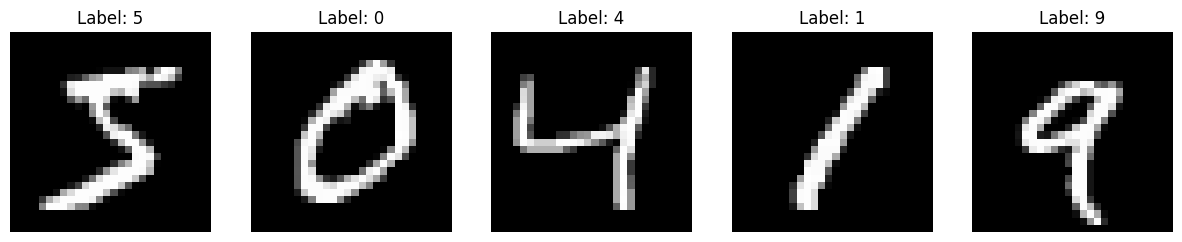

In [1]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Define the transformation to convert image to tensor
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load the MNIST dataset (train)
mnist_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Get the first few images from the dataset
images, labels = zip(*[mnist_dataset[i] for i in range(5)])

# Plot the images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {labels[i]}")
    axes[i].axis('off')

plt.show()


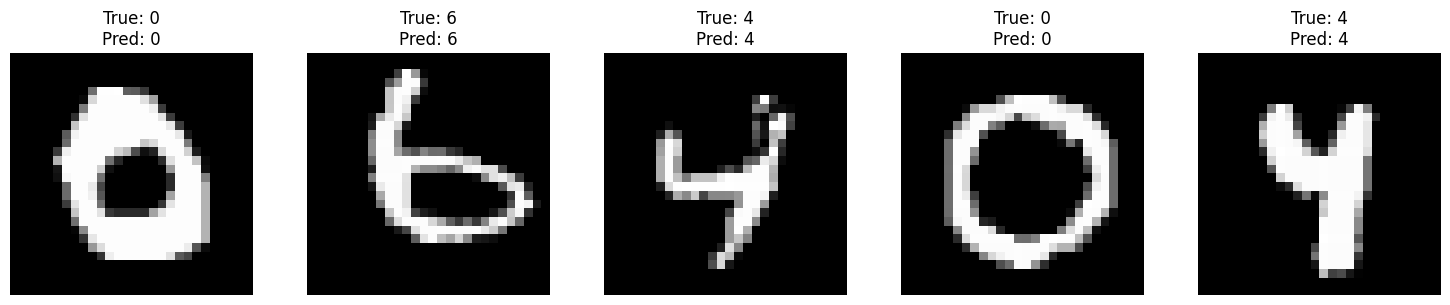

In [2]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 1: Load the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Step 2: Extract images and labels
train_images = train_dataset.data.numpy()
train_labels = train_dataset.targets.numpy()
test_images = test_dataset.data.numpy()
test_labels = test_dataset.targets.numpy()

# Step 3: Flatten images for classifier input
train_images_flat = train_images.reshape(len(train_images), -1)
test_images_flat = test_images.reshape(len(test_images), -1)

# Step 4: Normalize data
scaler = StandardScaler()
train_images_flat = scaler.fit_transform(train_images_flat)
test_images_flat = scaler.transform(test_images_flat)

# Step 5: Train a classifier (example: SVM)
svm_classifier = SVC()
svm_classifier.fit(train_images_flat, train_labels)

# Step 6: Predict on test images
predictions = svm_classifier.predict(test_images_flat)

# Step 7: Display some images with predicted and true labels
import random

# Choose 5 random images to show
indices = random.sample(range(len(test_dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(indices):
    img = test_images[idx]
    true_label = test_labels[idx]
    pred_label = predictions[idx]

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


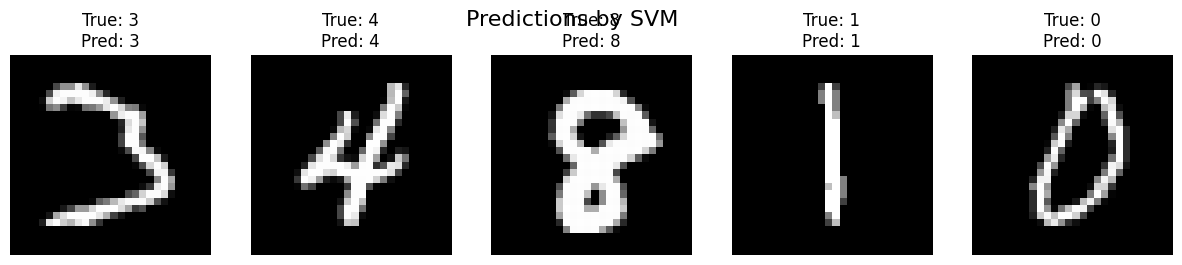

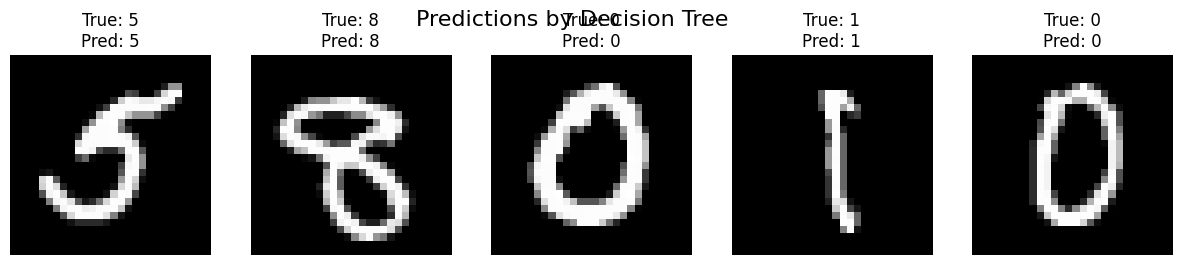

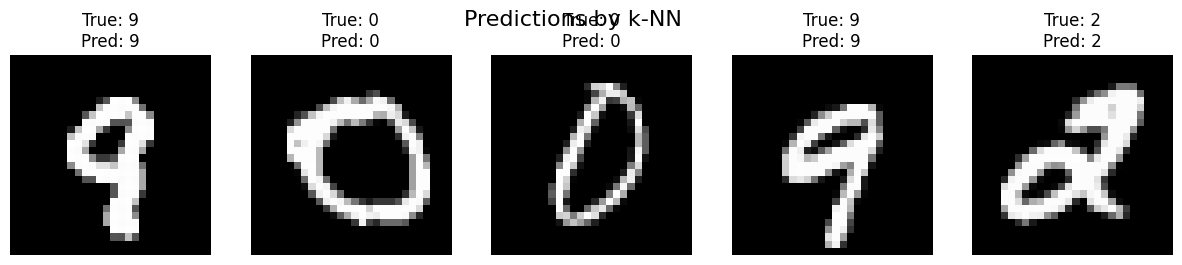

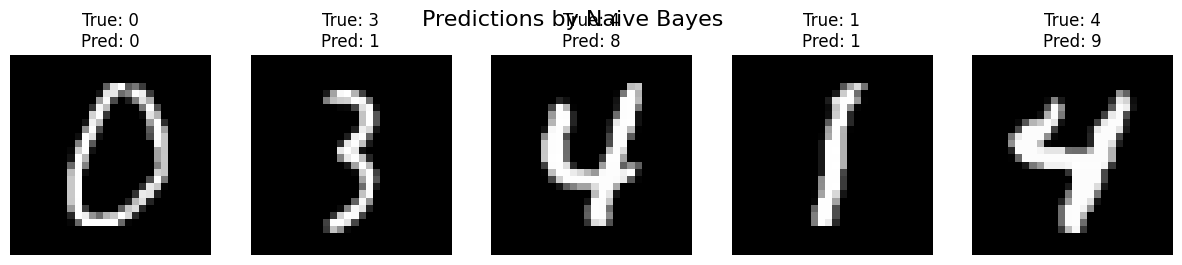

In [3]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
import numpy as np
import random

# Step 1: Load the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Step 2: Prepare images and labels
train_images = train_dataset.data.numpy()
train_labels = train_dataset.targets.numpy()
test_images = test_dataset.data.numpy()
test_labels = test_dataset.targets.numpy()

# Step 3: Flatten images
train_images_flat = train_images.reshape(len(train_images), -1)
test_images_flat = test_images.reshape(len(test_images), -1)

# Step 4: Normalize
scaler = StandardScaler()
train_images_flat = scaler.fit_transform(train_images_flat)
test_images_flat = scaler.transform(test_images_flat)

# Step 5: Train classifiers
svm_clf = SVC()
svm_clf.fit(train_images_flat, train_labels)

dt_clf = DecisionTreeClassifier()
dt_clf.fit(train_images_flat, train_labels)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(train_images_flat, train_labels)

nb_clf = GaussianNB()
nb_clf.fit(train_images_flat, train_labels)

# Step 6: Predict
svm_preds = svm_clf.predict(test_images_flat)
dt_preds = dt_clf.predict(test_images_flat)
knn_preds = knn_clf.predict(test_images_flat)
nb_preds = nb_clf.predict(test_images_flat)

# Step 7: Show results for each classifier
def plot_predictions(predictions, classifier_name):
    indices = random.sample(range(len(test_dataset)), 5)  # 5 random images
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f'Predictions by {classifier_name}', fontsize=16)
    for i, idx in enumerate(indices):
        img = test_images[idx]
        true_label = test_labels[idx]
        pred_label = predictions[idx]

        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}')
        axes[i].axis('off')
    plt.show()

# Plot for each classifier
plot_predictions(svm_preds, "SVM")
plot_predictions(dt_preds, "Decision Tree")
plot_predictions(knn_preds, "k-NN")
plot_predictions(nb_preds, "Naive Bayes")


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.71MB/s]


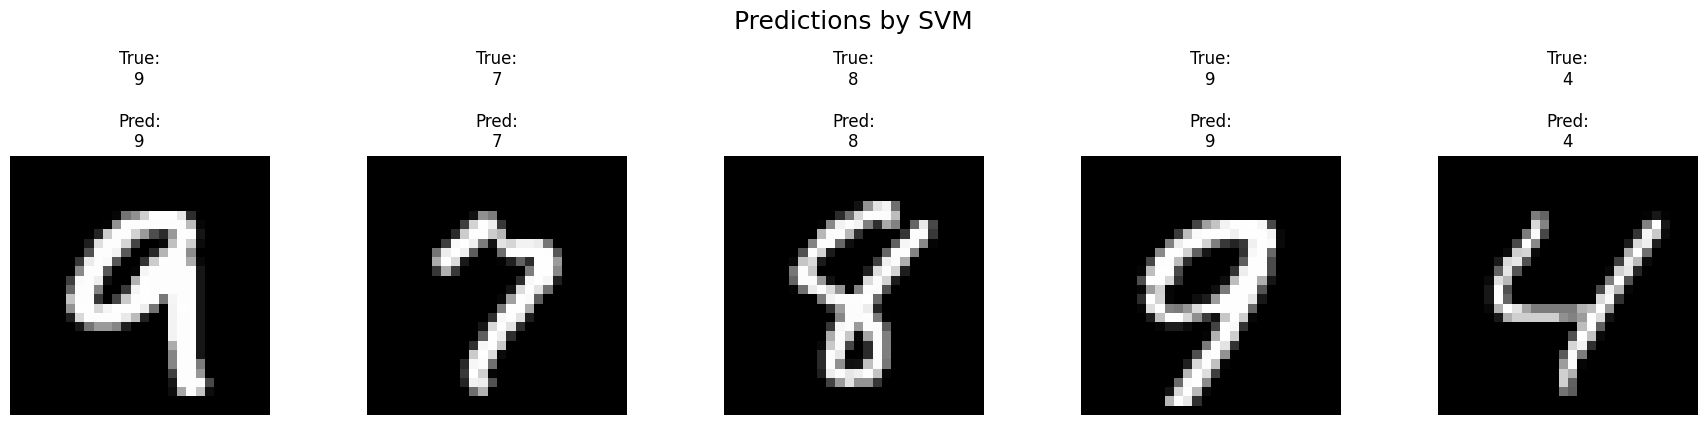

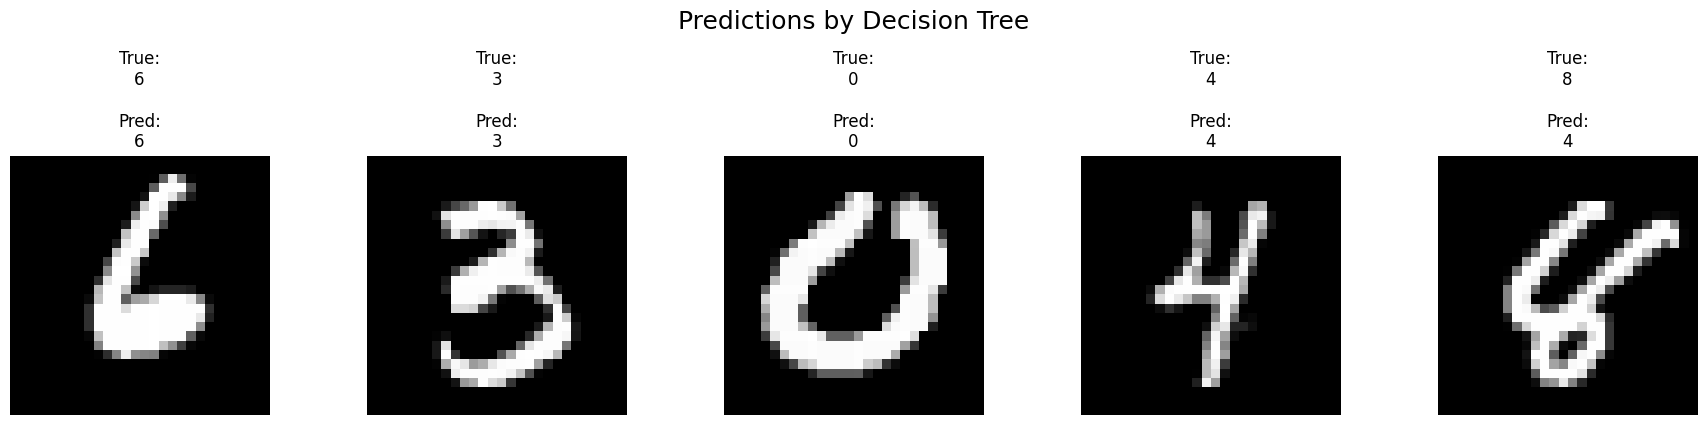

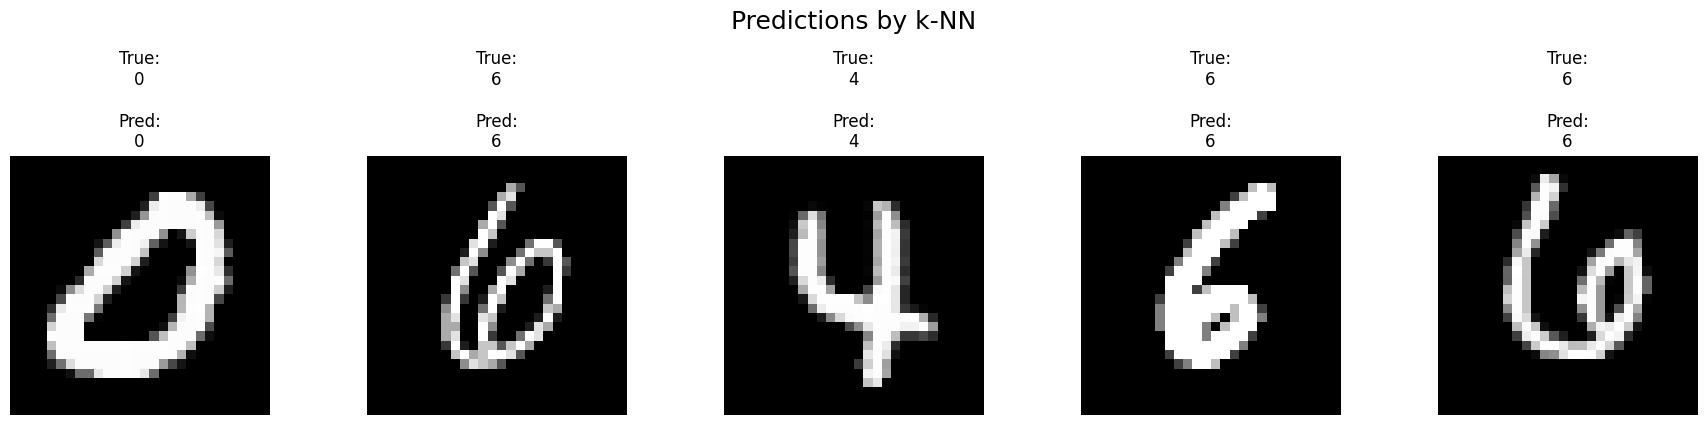

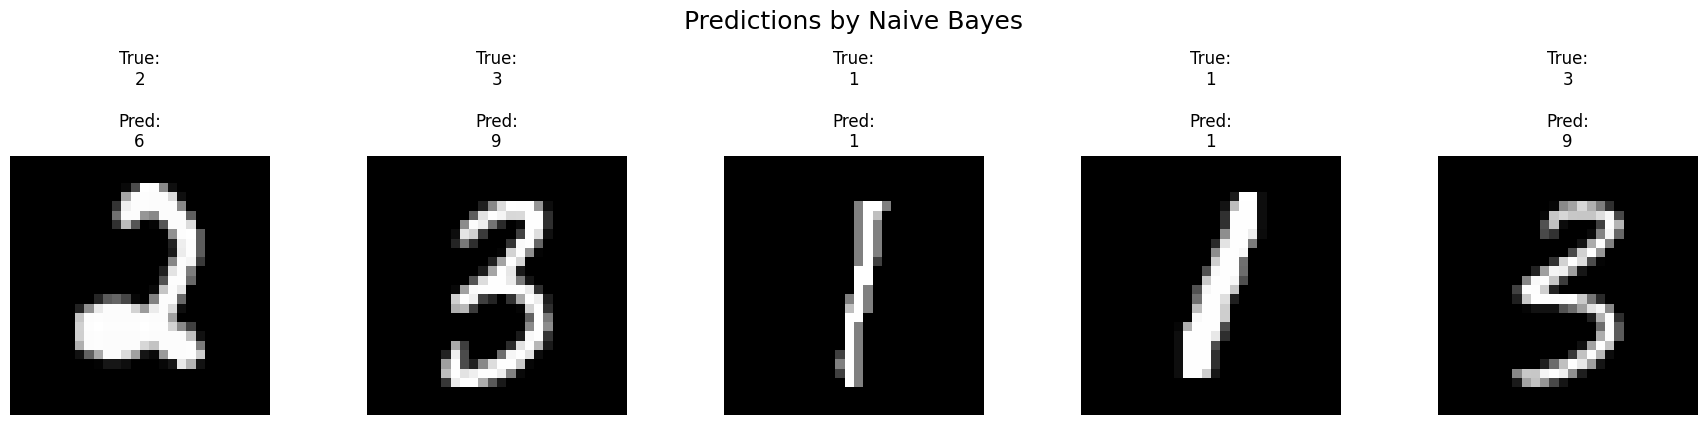

In [1]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
import numpy as np
import random

# Step 1: Load the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Step 2: Prepare images and labels
train_images = train_dataset.data.numpy()
train_labels = train_dataset.targets.numpy()
test_images = test_dataset.data.numpy()
test_labels = test_dataset.targets.numpy()

# Step 3: Flatten images
train_images_flat = train_images.reshape(len(train_images), -1)
test_images_flat = test_images.reshape(len(test_images), -1)

# Step 4: Normalize
scaler = StandardScaler()
train_images_flat = scaler.fit_transform(train_images_flat)
test_images_flat = scaler.transform(test_images_flat)

# Step 5: Train classifiers
svm_clf = SVC()
svm_clf.fit(train_images_flat, train_labels)

dt_clf = DecisionTreeClassifier()
dt_clf.fit(train_images_flat, train_labels)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(train_images_flat, train_labels)

nb_clf = GaussianNB()
nb_clf.fit(train_images_flat, train_labels)

# Step 6: Predict
svm_preds = svm_clf.predict(test_images_flat)
dt_preds = dt_clf.predict(test_images_flat)
knn_preds = knn_clf.predict(test_images_flat)
nb_preds = nb_clf.predict(test_images_flat)

# Step 7: Show results for each classifier
def plot_predictions(predictions, classifier_name):
    indices = random.sample(range(len(test_dataset)), 5)  # 5 random images
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))  # made it a bit wider
    fig.suptitle(f'Predictions by {classifier_name}', fontsize=18, y=1.05)
    for i, idx in enumerate(indices):
        img = test_images[idx]
        true_label = test_labels[idx]
        pred_label = predictions[idx]

        axes[i].imshow(img, cmap='gray')
        # Add vertical space between True and Pred
        axes[i].set_title(f'True:\n{true_label}\n\nPred:\n{pred_label}', fontsize=12)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Plot for each classifier
plot_predictions(svm_preds, "SVM")
plot_predictions(dt_preds, "Decision Tree")
plot_predictions(knn_preds, "k-NN")
plot_predictions(nb_preds, "Naive Bayes")
